# PyTorch training with nn.Linear / nn.Linear ile PyTorch eğitimi

**English**

- **Goal:** predict grades from study hours using a standard PyTorch linear layer.
- **Model:** `nn.Linear(1, 1)` manages the trainable weight and bias.
- **Roadmap:** prepare `(N, 1)` float32 tensors → split data → define the layer → train and evaluate → compare predictions with true grades.
- Run from top to bottom. Compared with the manual notebook, this version uses `nn.Linear`, runs 120 epochs, and visualizes predictions. Different initialization and epoch counts mean results need not be identical.

**Türkçe**

- **Amaç:** standart PyTorch doğrusal katmanıyla çalışma süresinden not tahmin etmek.
- **Model:** `nn.Linear(1, 1)` öğrenilebilir ağırlık ve bias değerlerini yönetir.
- **Akış:** `(N, 1)` şeklinde float32 tensörleri hazırla → veriyi ayır → katmanı tanımla → eğit ve değerlendir → tahminlerle gerçek notları karşılaştır.
- Yukarıdan aşağıya çalıştır. Elle tanımlanan notebook’a göre bu sürüm `nn.Linear` kullanır, 120 epoch çalışır ve tahminleri görselleştirir. Başlangıç değerleri ve epoch sayıları farklı olduğundan sonuçların aynı olması gerekmez.


## 1. Import libraries / Kütüphaneleri içe aktar

**English**

Pandas reads the CSV, PyTorch creates tensors and trains the model, and Matplotlib draws graphs. NumPy is imported as `np`, but is not directly used in the following cells.

**Türkçe**

Pandas CSV’yi okur, PyTorch tensörleri oluşturup modeli eğitir, Matplotlib grafikleri çizer. NumPy `np` adıyla içe aktarılır ancak sonraki hücrelerde doğrudan kullanılmaz.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

## 2. Load the dataset / Veri setini yükle

**English**

Read the CSV into `df`. The relative path assumes the notebook runs from this folder. `study_hours` is the input and `grade` is the value to predict.

**Türkçe**

CSV dosyasını `df` içine oku. Göreli yol, notebook’un bu klasörden çalıştırıldığını varsayar. `study_hours` girdidir; `grade` tahmin edilecek değerdir.


In [2]:
df = pd.read_csv("../data/06-study_hours_grades.csv")

## 3. Preview the data / Veriye göz at

**English**

`df.head()` shows the first five rows by default. Inspect the `study_hours` input and the `grade` target before conversion.

**Türkçe**

`df.head()` varsayılan olarak ilk beş satırı gösterir. Dönüşümden önce `study_hours` girdisini ve `grade` hedefini incele.


In [3]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


## 4. Prepare layer-compatible tensors / Katmana uygun tensörleri hazırla

**English**

Create `X` and `y` with `dtype=torch.float32`, matching the default dtype of the linear layer. `unsqueeze(1)` adds a second axis: `(N,)` becomes `(N, 1)`. Each row is one sample with one feature or one target, keeping predictions and targets the same shape for MSE.

**Türkçe**

`X` ve `y` tensörlerini doğrusal katmanın varsayılan türüne uygun `dtype=torch.float32` ile oluştur. `unsqueeze(1)` ikinci bir eksen ekler: `(N,)`, `(N, 1)` olur. Her satır tek özellikli veya tek hedefli bir örnektir; MSE için tahmin ve hedef şekilleri eşleşir.


In [4]:
X = torch.tensor(df["study_hours"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype=torch.float32).unsqueeze(1)

## 5. Check the shape / Şekli kontrol et

**English**

`X.shape` returns `(N, 1)`: `N` samples and one input feature per sample. `nn.Linear(in_features=1, ...)` expects this final feature dimension.

**Türkçe**

`X.shape`, `(N, 1)` döndürür: `N` örnek ve örnek başına bir girdi özelliği. `nn.Linear(in_features=1, ...)` son eksendeki özellik sayısının bir olmasını bekler.


In [5]:
X.shape

torch.Size([50, 1])

## 6. Check the number of axes / Eksen sayısını kontrol et

**English**

`X.ndim` is 2 because `X` has a sample axis and a feature axis. Two axes do not mean two input features; there is still one feature per sample.

**Türkçe**

`X.ndim` değeri 2’dir; çünkü `X` bir örnek ve bir özellik eksenine sahiptir. İki eksen, iki girdi özelliği anlamına gelmez; örnek başına hâlâ bir özellik vardır.


In [6]:
X.ndim

2

## 7. Split inputs and targets / Girdi ve hedefleri ayır

**English**

Use the first 80% of samples (rounded down) for training and the remainder for testing. Identical slicing keeps inputs and targets aligned. This is an ordered split without shuffling, so sorted data can yield different train/test distributions.

**Türkçe**

Örneklerin ilk %80’ini (aşağı yuvarlayarak) eğitim, kalanını test için kullan. Aynı dilimleme girdilerle hedefleri eşleştirir. Bu, karıştırma yapılmayan sıralı bir ayrımdır; sıralı veri farklı eğitim/test dağılımları oluşturabilir.


In [7]:
train_split = int(len(X) * 0.8)

X_train = X[:train_split]
y_train = y[:train_split]

X_test = X[train_split:]
y_test = y[train_split:]

## 8. Visualize the split / Veri ayrımını görselleştir

**English**

Plot study hours on the horizontal axis and grades on the vertical axis for each subset. `label` names the series, but this cell does not call `plt.legend()`, so those labels are not shown as a legend.

**Türkçe**

Her alt küme için yatay eksende çalışma süresini, dikey eksende notları çiz. `label` serileri adlandırır; bu hücre `plt.legend()` çağırmadığı için etiketler açıklama kutusunda gösterilmez.


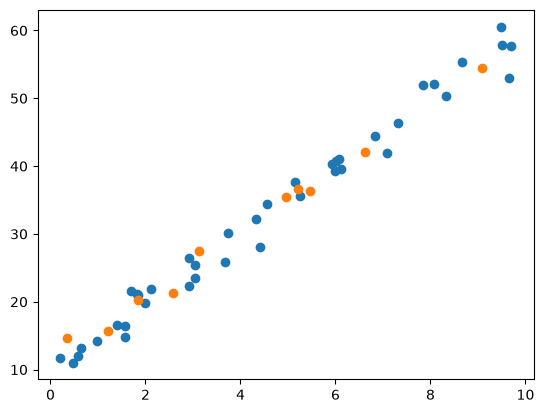

In [8]:
plt.scatter(X_train, y_train, label="Training Dataset")
plt.scatter(X_test, y_test, label="Test Dataset")
plt.show()

## 9. Define an nn.Linear model / nn.Linear modeli tanımla

**English**

Inherit from `nn.Module` and initialize the base class. `nn.Linear(in_features=1, out_features=1)` creates a trainable weight and bias for `y_hat = x * weight + bias`. `forward()` passes inputs through the layer. This packages the manually defined calculation in the other notebook into a standard PyTorch layer.

**Türkçe**

`nn.Module` sınıfından türe ve temel sınıfı başlat. `nn.Linear(in_features=1, out_features=1)`, `y_hat = x * weight + bias` için öğrenilebilir ağırlık ve bias oluşturur. `forward()` girdileri katmandan geçirir. Böylece diğer notebook’ta elle tanımlanan hesaplama standart bir PyTorch katmanıyla yapılır.


In [9]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

## 10. Initialize the model / Modeli başlat

**English**

`torch.manual_seed(42)` makes random initialization repeatable in the same environment. Constructing `LinearRegressionModel()` creates the layer parameters; no training has happened yet.

**Türkçe**

`torch.manual_seed(42)` aynı ortamda rastgele başlangıcı tekrarlanabilir yapar. `LinearRegressionModel()` oluşturulunca katman parametreleri de oluşturulur; henüz eğitim gerçekleşmedi.


In [10]:
torch.manual_seed(42)
model = LinearRegressionModel()

## 11. Inspect the architecture / Model yapısını incele

**English**

Display `model` to see the registered `linear_layer`: one input feature, one output feature, and an enabled bias.

**Türkçe**

Kayıtlı `linear_layer` katmanını görmek için `model` nesnesini göster: bir girdi özelliği, bir çıktı özelliği ve etkin bias.


In [11]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

## 12. Inspect initial layer parameters / Katmanın başlangıç parametrelerini incele

**English**

`state_dict()` displays `linear_layer.weight` with shape `(1, 1)` and `linear_layer.bias` with shape `(1,)`. These are the initial trainable values; displaying them does not save the model.

**Türkçe**

`state_dict()`, `(1, 1)` şeklindeki `linear_layer.weight` ve `(1,)` şeklindeki `linear_layer.bias` değerlerini gösterir. Bunlar başlangıçtaki öğrenilebilir değerlerdir; gösterilmeleri modeli kaydetmez.


In [12]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

## 13. Choose loss and optimizer / Kayıp ve optimizer seç

**English**

MSE measures the average squared prediction error. SGD receives `model.parameters()` so it can update the layer weight and bias. The learning rate `0.001` scales each gradient-based update.

**Türkçe**

MSE, tahmin hatalarının karelerinin ortalamasını ölçer. SGD, katmanın ağırlık ve bias değerlerini güncellemek için `model.parameters()` alır. `0.001` öğrenme oranı, gradyana dayalı her güncellemenin büyüklüğünü ölçekler.


In [13]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)

## 14. Run the training loop / Eğitim döngüsünü çalıştır

**English**

Train for 120 epochs, with one update on the whole training set per epoch.

1. `model.train()` selects training mode.
2. `model(X_train)` performs the forward pass.
3. `loss_fn(y_pred, y_train)` measures training MSE.
4. `optimizer.zero_grad()` clears accumulated gradients.
5. `loss.backward()` computes parameter gradients.
6. `optimizer.step()` updates the layer parameters.
7. `model.eval()` selects evaluation mode; `torch.inference_mode()` disables gradient tracking while test predictions and MSE are computed.
8. Print both losses every five epochs. Unlike the other notebook, this loop does not store loss history for a graph.

Training loss is measured before the update and test loss after it. Calling `train()` or `eval()` alone does not update weights, and `eval()` alone does not disable gradients. Use a separate validation set when tuning the model so the final test set remains reserved for the end.

**Türkçe**

120 epoch eğit; her epoch’ta tüm eğitim kümesiyle tek güncelleme yap.

1. `model.train()` eğitim modunu seçer.
2. `model(X_train)` ileri yayılımı gerçekleştirir.
3. `loss_fn(y_pred, y_train)` eğitim MSE değerini ölçer.
4. `optimizer.zero_grad()` biriken gradyanları temizler.
5. `loss.backward()` parametre gradyanlarını hesaplar.
6. `optimizer.step()` katman parametrelerini günceller.
7. `model.eval()` değerlendirme modunu seçer; `torch.inference_mode()` test tahminleri ve MSE hesaplanırken gradyan takibini kapatır.
8. Her beş epoch’ta iki kaybı yazdır. Diğer notebook’tan farklı olarak bu döngü grafik için kayıp geçmişini saklamaz.

Eğitim kaybı güncellemeden önce, test kaybı sonra ölçülür. Tek başına `train()` veya `eval()` ağırlıkları güncellemez; tek başına `eval()` gradyanları kapatmaz. Modeli ayarlarken ayrı doğrulama kümesi kullanarak son test kümesini en sona sakla.


In [14]:
epochs = 120

for epoch in range(epochs):

    model.train()

    y_pred = model(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 5 == 0:
            print(f"Epoch : {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")

Epoch : 0, Train Loss: 965.6339721679688, Test Loss: 717.683349609375
Epoch : 5, Train Loss: 530.086669921875, Test Loss: 405.685546875
Epoch : 10, Train Loss: 295.7361755371094, Test Loss: 236.03225708007812
Epoch : 15, Train Loss: 169.6184539794922, Test Loss: 143.42544555664062
Epoch : 20, Train Loss: 101.72415924072266, Test Loss: 92.61089324951172
Epoch : 25, Train Loss: 65.15110778808594, Test Loss: 64.53108215332031
Epoch : 30, Train Loss: 45.427330017089844, Test Loss: 48.86598587036133
Epoch : 35, Train Loss: 34.767799377441406, Test Loss: 40.014488220214844
Epoch : 40, Train Loss: 28.984630584716797, Test Loss: 34.92718505859375
Epoch : 45, Train Loss: 25.824926376342773, Test Loss: 31.93711280822754
Epoch : 50, Train Loss: 24.0767879486084, Test Loss: 30.128173828125
Epoch : 55, Train Loss: 23.088253021240234, Test Loss: 28.993366241455078
Epoch : 60, Train Loss: 22.508625030517578, Test Loss: 28.2496337890625
Epoch : 65, Train Loss: 22.14923667907715, Test Loss: 27.73709678

## 15. Inspect trained parameters / Eğitilmiş parametreleri incele

**English**

Display the learned layer weight and bias. Compare them with the initial state to see the effect of the optimizer updates. The weight gives the fitted grade change per study hour; the bias gives the prediction at zero hours.

**Türkçe**

Katmanın öğrenilen ağırlık ve bias değerlerini göster. Optimizer güncellemelerinin etkisini görmek için başlangıç durumuyla karşılaştır. Ağırlık, çalışma saati başına öğrenilen not değişimini; bias, sıfır saatteki tahmini verir.


In [15]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[6.2079]])),
             ('linear_layer.bias', tensor([2.2388]))])

## 16. Make test predictions / Test tahminlerini üret

**English**

Set evaluation mode and run the trained model on `X_test` with gradient tracking disabled. Store the outputs in `y_preds`; this cell does not train or update the model.

**Türkçe**

Değerlendirme modunu aç ve eğitilmiş modeli gradyan takibi kapalıyken `X_test` üzerinde çalıştır. Çıktıları `y_preds` içine kaydet; bu hücre modeli eğitmez veya güncellemez.


In [17]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

## 17. Inspect predictions / Tahminleri incele

**English**

Display `y_preds`, the predicted grades with shape `(N_test, 1)`. Each prediction corresponds to the test input at the same index.

**Türkçe**

`(N_test, 1)` şeklindeki tahmini notları, yani `y_preds` tensörünü göster. Her tahmin aynı indeksteki test girdisine karşılık gelir.


In [18]:
y_preds

tensor([[ 9.8148],
        [32.9787],
        [ 4.3736],
        [58.6882],
        [18.3035],
        [43.3673],
        [21.5894],
        [34.5239],
        [36.1778],
        [13.7143]])

## 18. Inspect true test grades / Gerçek test notlarını incele

**English**

Display `y_test` and compare it with `y_preds` at matching indices. The difference between each pair is a prediction error; MSE summarizes the squared errors.

**Türkçe**

`y_test` tensörünü göster ve aynı indekslerdeki `y_preds` değerleriyle karşılaştır. Her çift arasındaki fark bir tahmin hatasıdır; MSE bu hataların karelerini özetler.


In [19]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

## 19. Compare predictions visually / Tahminleri görsel olarak karşılaştır

**English**

Plot training samples, true test grades, and predicted test grades against study hours. The vertical gap between a test point and its prediction shows its error. The predicted points lie on the fitted straight line. `label` values are defined, but a legend requires a `plt.legend()` call.

**Türkçe**

Eğitim örneklerini, gerçek test notlarını ve tahmini test notlarını çalışma sürelerine göre çiz. Bir test noktasıyla tahmini arasındaki dikey fark hatayı gösterir. Tahmin noktaları öğrenilen doğru üzerinde yer alır. `label` değerleri tanımlıdır; açıklama kutusu için `plt.legend()` çağrısı gerekir.


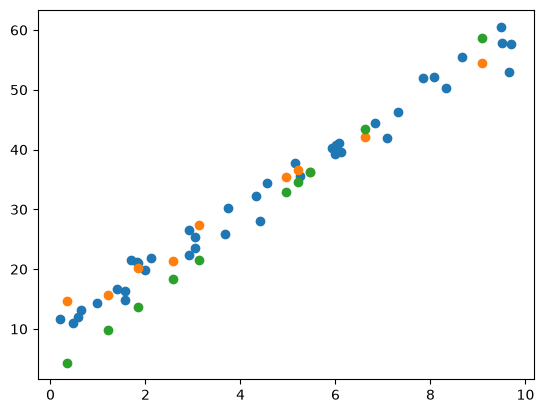

In [20]:
plt.scatter(X_train, y_train, label="Training Dataset")
plt.scatter(X_test, y_test, label="Test Dataset")
plt.scatter(X_test, y_preds, label="Predictions")
plt.show()